# GBM-Probe JRN Estimation on rel-hm (H&M)

**Join Reproduction Number (JRN)** estimation on the rel-hm (H&M) relational dataset using LightGBM probes.

This notebook demonstrates:
- **Phase 1**: Baseline + JRN estimation for 2 tasks × multiple aggregation types
- **Phase 2**: Fan-out stratified JRN estimation (by join cardinality buckets)
- **Phase 3**: FK-shuffling confound decomposition (structural vs feature JRN)
- **Phase 4**: Aggregation sensitivity analysis (CoV, spread)
- **Phase 5**: JRN-guided vs uniform architecture comparison

**Key concept**: JRN > 1 means the join *improves* prediction. JRN < 1 means it *hurts*.
For regression (MAE), we use JRN = baseline_MAE / augmented_MAE so JRN > 1 always means improvement.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# lightgbm, loguru, psutil — NOT pre-installed on Colab, always install
_pip('lightgbm==4.6.0', 'loguru==0.7.3', 'psutil==7.0.0')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python>=3.11; use latest compatible for local testing
    _pip('scipy>=1.13,<1.16')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, roc_auc_score
import lightgbm as lgb
import matplotlib.pyplot as plt
from loguru import logger

# Configure logging for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

Load the mini demo dataset from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-bc07ab-join-reproduction-number-epidemiology-in/main/experiment_iter5_gbm_probe_jrn_e/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'][0]['examples'])} examples")

Loaded 269 examples


## Configuration

All tunable parameters. Starting with minimum values for fast execution.

In [5]:
# === CONFIG: Tunable parameters ===
# Scaled up to original values (runtime ~1s with mini data, well within 300s budget)

SEEDS = [42, 123, 456]                          # Original: [42, 123, 456]
AGG_TYPES = ["mean", "sum", "max", "std", "all_combined"]  # Original: all 5
N_PERMUTATIONS = 5                               # Original: 5

PROBE_CONFIG = {
    "n_estimators": 200,        # Original: 200
    "max_depth": 6,             # Original: 6
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "verbose": -1,
    "n_jobs": 1,
}

FULL_CONFIG = {
    "n_estimators": 500,        # Original: 500
    "max_depth": 8,             # Original: 8
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "num_leaves": 127,          # Original: 127
    "verbose": -1,
    "n_jobs": 1,
}

TASK_CONFIG = {
    "user-churn": {
        "entity_table": "customers", "entity_col": "customer_id",
        "task_type": "classification", "metric": "AUROC", "higher_is_better": True,
        "join": {"child_table": "transactions", "fk_col": "customer_id"},
    },
    "item-sales": {
        "entity_table": "articles", "entity_col": "article_id",
        "task_type": "regression", "metric": "MAE", "higher_is_better": False,
        "join": {"child_table": "transactions", "fk_col": "article_id"},
    },
}

FAN_OUT_BUCKETS = [
    (1, 5, "1-5"), (6, 20, "6-20"), (21, 50, "21-50"),
    (51, 200, "51-200"), (201, float("inf"), "200+"),
]

# Minimum samples for fan-out buckets (lower for demo data)
MIN_TRAIN_BUCKET = 5            # Original: 30
MIN_VAL_BUCKET = 3              # Original: 10
MIN_VAL_FOLD = 5                # Original: 100 (threshold for combining folds)

## Phase 0: Data Parsing & Feature Engineering

Parse the raw JSON examples into per-table DataFrames (customers, articles, transactions) and encode categorical features for LightGBM.

In [6]:
# Parse examples from loaded data into per-table DataFrames
customers_records = []
articles_records = []
transactions_records = []

examples = data["datasets"][0]["examples"]
logger.info(f"Parsing {len(examples)} examples...")

for ex in examples:
    table = ex["metadata_table"]
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    fold = ex["metadata_fold"]
    fan_out = ex.get("metadata_fan_out", 0)
    fan_out_bucket = ex.get("metadata_fan_out_bucket", "")

    feats = inp["features"]
    row_id = inp["row_id"]

    if table == "customers":
        customers_records.append({
            "_row_id": row_id, "_fold": fold,
            "_fan_out": fan_out, "_fan_out_bucket": fan_out_bucket,
            "_label_churn": out.get("user-churn"),
            "FN": feats.get("FN"), "Active": feats.get("Active"),
            "club_member_status": feats.get("club_member_status"),
            "fashion_news_frequency": feats.get("fashion_news_frequency"),
            "age": feats.get("age"),
        })
    elif table == "articles":
        rec = {
            "_row_id": row_id, "_fold": fold,
            "_fan_out": fan_out, "_fan_out_bucket": fan_out_bucket,
            "_label_sales": out.get("item-sales"),
        }
        for k, v in feats.items():
            if k in ("prod_name", "detail_desc", "article_id"):
                continue
            rec[k] = v
        articles_records.append(rec)
    elif table == "transactions":
        transactions_records.append({
            "_row_id": row_id, "_fold": fold,
            "_fan_out": fan_out, "_fan_out_bucket": fan_out_bucket,
            "customer_id": feats.get("customer_id"),
            "article_id": feats.get("article_id"),
            "price": feats.get("price"),
            "sales_channel_id": feats.get("sales_channel_id"),
        })

customers_df = pd.DataFrame(customers_records)
articles_df = pd.DataFrame(articles_records)
transactions_df = pd.DataFrame(transactions_records)

logger.info(f"Data parsed: customers={len(customers_df)}, articles={len(articles_df)}, transactions={len(transactions_df)}")
del customers_records, articles_records, transactions_records
gc.collect()

17:20:13|INFO   |Parsing 269 examples...


17:20:13|INFO   |Data parsed: customers=84, articles=85, transactions=100


0

In [7]:
# Encode features for LightGBM
logger.info("Encoding features...")

# --- Customers ---
for col in ["FN", "Active", "age"]:
    if col in customers_df.columns:
        customers_df[col] = pd.to_numeric(customers_df[col], errors="coerce")

for col in ["club_member_status", "fashion_news_frequency"]:
    if col in customers_df.columns:
        customers_df[col] = customers_df[col].astype("category").cat.codes.replace(-1, np.nan)

# --- Articles ---
meta_cols = [c for c in articles_df.columns if c.startswith("_")]
feat_cols = [c for c in articles_df.columns if not c.startswith("_")]

for col in feat_cols:
    converted = pd.to_numeric(articles_df[col], errors="coerce")
    non_null_orig = articles_df[col].notna().sum()
    non_null_conv = converted.notna().sum()
    if non_null_conv >= non_null_orig * 0.8:
        articles_df[col] = converted
    else:
        nunique = articles_df[col].nunique()
        if nunique < 1000:
            articles_df[col] = articles_df[col].astype("category").cat.codes.replace(-1, np.nan)
        else:
            articles_df.drop(columns=[col], inplace=True)

# --- Transactions ---
for col in ["price", "sales_channel_id"]:
    if col in transactions_df.columns:
        transactions_df[col] = pd.to_numeric(transactions_df[col], errors="coerce")

logger.info(f"Customer features: {[c for c in customers_df.columns if not c.startswith('_')]}")
logger.info(f"Article features: {[c for c in articles_df.columns if not c.startswith('_')][:10]}")
logger.info(f"Transaction features: {[c for c in transactions_df.columns if not c.startswith('_')]}")

17:20:13|INFO   |Encoding features...


17:20:13|INFO   |Customer features: ['FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age']


17:20:13|INFO   |Article features: ['product_code', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name']


17:20:13|INFO   |Transaction features: ['customer_id', 'article_id', 'price', 'sales_channel_id']


## Helper Functions

Core utilities: feature column selection, transaction aggregation, LightGBM training, and JRN computation.

In [8]:
def get_entity_feat_cols(df):
    """Return entity feature columns (non-meta)."""
    return [c for c in df.columns if not c.startswith("_")]


def aggregate_transactions(transactions_df, fk_col, agg_type):
    """Aggregate transaction features to entity level."""
    txn_feat_cols = ["price", "sales_channel_id"]
    available_cols = [c for c in txn_feat_cols if c in transactions_df.columns]

    if agg_type == "all_combined":
        agg_funcs = ["mean", "sum", "max", "std", "min"]
        agg_dict = {col: agg_funcs for col in available_cols}
        grouped = transactions_df.groupby(fk_col)[available_cols].agg(agg_dict)
        grouped.columns = [f"txn_{col}_{func}" for col, func in grouped.columns]
    else:
        grouped = transactions_df.groupby(fk_col)[available_cols].agg(agg_type)
        grouped.columns = [f"txn_{col}_{agg_type}" for col in grouped.columns]

    counts = transactions_df.groupby(fk_col).size().rename("txn_count")
    grouped = grouped.join(counts)
    grouped = grouped.reset_index()
    return grouped


def train_and_evaluate(X_train, y_train, X_val, y_val, task_type, config, seed):
    """Train LightGBM and evaluate."""
    params = {**config, "random_state": seed}
    if task_type == "classification":
        if y_val.nunique() < 2:
            return float("nan")
        model = lgb.LGBMClassifier(**params, class_weight="balanced")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(X_train, y_train)
        preds = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, preds)
    else:
        model = lgb.LGBMRegressor(**params)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(X_train, y_train)
        preds = model.predict(X_val)
        score = mean_absolute_error(y_val, preds)
    del model
    return score


def compute_jrn(baseline_score, augmented_score, higher_is_better):
    """Compute JRN with CORRECTED direction for lower-is-better metrics."""
    if higher_is_better:
        return augmented_score / baseline_score if baseline_score > 0 else 1.0
    else:
        return baseline_score / augmented_score if augmented_score > 0 else 1.0

## Phase 1: Baseline + JRN Estimation

For each task (user-churn classification, item-sales regression), train a baseline LightGBM on entity features only, then train augmented models with joined transaction features. JRN = ratio of scores.

In [9]:
start_time = time.time()
logger.info("=" * 60)
logger.info("PHASE 1: Baseline + JRN Estimation")
logger.info("=" * 60)

phase1_results = {}

for task_name, task_cfg in TASK_CONFIG.items():
    logger.info(f"\n--- Task: {task_name} ({task_cfg['task_type']}) ---")
    entity_table = task_cfg["entity_table"]
    fk_col = task_cfg["join"]["fk_col"]
    task_type = task_cfg["task_type"]
    higher_is_better = task_cfg["higher_is_better"]

    if entity_table == "customers":
        entity_df = customers_df.copy()
        label_col = "_label_churn"
    else:
        entity_df = articles_df.copy()
        label_col = "_label_sales"

    entity_feat_cols = get_entity_feat_cols(entity_df)
    entity_feat_cols = [c for c in entity_feat_cols if c != label_col]

    train_mask = entity_df["_fold"] == 0
    has_label = entity_df[label_col].notna()
    train_idx = entity_df[train_mask & has_label].index

    val_fold1 = entity_df[(entity_df["_fold"] == 1) & has_label]
    val_fold2 = entity_df[(entity_df["_fold"] == 2) & has_label]
    if len(val_fold1) < MIN_VAL_FOLD or len(val_fold2) < MIN_VAL_FOLD:
        val_mask = (entity_df["_fold"] == 1) | (entity_df["_fold"] == 2)
        val_idx = entity_df[val_mask & has_label].index
        logger.info(f"  Combined fold 1+2 for val: {len(val_fold1)}+{len(val_fold2)}={len(val_idx)}")
    else:
        val_idx = val_fold1.index

    logger.info(f"  Entity: {entity_table}, train={len(train_idx)}, val={len(val_idx)}")

    X_train_base = entity_df.loc[train_idx, entity_feat_cols].copy()
    y_train = entity_df.loc[train_idx, label_col].copy()
    X_val_base = entity_df.loc[val_idx, entity_feat_cols].copy()
    y_val = entity_df.loc[val_idx, label_col].copy()

    for col in X_train_base.columns:
        X_train_base[col] = pd.to_numeric(X_train_base[col], errors="coerce")
        X_val_base[col] = pd.to_numeric(X_val_base[col], errors="coerce")

    # --- Baseline ---
    logger.info(f"  Training baseline ({len(entity_feat_cols)} features)...")
    baseline_scores = []
    for seed in SEEDS:
        try:
            score = train_and_evaluate(X_train_base, y_train, X_val_base, y_val,
                                       task_type, PROBE_CONFIG, seed)
            if not np.isnan(score):
                baseline_scores.append(score)
        except Exception as e:
            logger.warning(f"  Baseline failed seed={seed}: {e}")

    baseline_mean = np.mean(baseline_scores) if baseline_scores else 0.0
    baseline_std = np.std(baseline_scores) if len(baseline_scores) > 1 else 0.0
    logger.info(f"  Baseline {task_cfg['metric']}: {baseline_mean:.4f} +/- {baseline_std:.4f}")

    # --- With-join for each agg type ---
    task_results = {
        "baseline": {"mean": baseline_mean, "std": baseline_std, "scores": baseline_scores},
        "agg_results": {},
    }

    for agg_type in AGG_TYPES:
        logger.info(f"  Aggregation: {agg_type}")
        try:
            agg_df = aggregate_transactions(transactions_df, fk_col, agg_type)
            agg_feat_cols = [c for c in agg_df.columns if c != fk_col]

            merged_train = entity_df.loc[train_idx].merge(
                agg_df, left_on="_row_id", right_on=fk_col, how="left")
            merged_val = entity_df.loc[val_idx].merge(
                agg_df, left_on="_row_id", right_on=fk_col, how="left")

            all_feat_cols = entity_feat_cols + agg_feat_cols
            all_feat_cols = [c for c in all_feat_cols if c in merged_train.columns]
            all_feat_cols = list(dict.fromkeys(all_feat_cols))

            X_train_aug = merged_train[all_feat_cols].copy()
            X_val_aug = merged_val[all_feat_cols].copy()
            for col in X_train_aug.columns:
                X_train_aug[col] = pd.to_numeric(X_train_aug[col], errors="coerce")
                X_val_aug[col] = pd.to_numeric(X_val_aug[col], errors="coerce")

            augmented_scores = []
            for seed in SEEDS:
                try:
                    score = train_and_evaluate(X_train_aug, y_train, X_val_aug, y_val,
                                               task_type, PROBE_CONFIG, seed)
                    if not np.isnan(score):
                        augmented_scores.append(score)
                except Exception as e:
                    logger.warning(f"  Augmented failed agg={agg_type}, seed={seed}: {e}")

            aug_mean = np.mean(augmented_scores) if augmented_scores else baseline_mean
            aug_std = np.std(augmented_scores) if len(augmented_scores) > 1 else 0.0
            jrn = compute_jrn(baseline_mean, aug_mean, higher_is_better)

            logger.info(f"    Augmented {task_cfg['metric']}: {aug_mean:.4f}, JRN = {jrn:.4f}")

            task_results["agg_results"][agg_type] = {
                "augmented_mean": aug_mean, "augmented_std": aug_std,
                "augmented_scores": augmented_scores,
                "jrn": jrn, "n_agg_features": len(agg_feat_cols),
            }
            del agg_df, merged_train, merged_val, X_train_aug, X_val_aug
            gc.collect()

        except Exception as e:
            logger.warning(f"  Failed agg_type={agg_type}: {e}")
            task_results["agg_results"][agg_type] = {
                "augmented_mean": baseline_mean, "augmented_std": 0.0,
                "jrn": 1.0, "error": "failed",
            }

    phase1_results[task_name] = task_results
    del entity_df
    gc.collect()

logger.info(f"Phase 1 completed in {time.time() - start_time:.1f}s")

17:20:13|INFO   |============================================================


17:20:13|INFO   |PHASE 1: Baseline + JRN Estimation


17:20:13|INFO   |============================================================


17:20:13|INFO   |
--- Task: user-churn (classification) ---


17:20:13|INFO   |  Entity: customers, train=51, val=15


...

17:20:14|INFO   |  Aggregation: std


17:20:14|INFO   |    Augmented MAE: 0.0973, JRN = 1.0000


17:20:14|INFO   |  Aggregation: all_combined


17:20:14|INFO   |    Augmented MAE: 0.0973, JRN = 1.0000


17:20:14|INFO   |Phase 1 completed in 0.6s


## Phase 2: Fan-Out Stratification

Compute JRN within fan-out buckets (1-5, 6-20, 21-50, etc.) to see how join cardinality affects JRN.

In [10]:
t2_start = time.time()
logger.info("=" * 60)
logger.info("PHASE 2: Fan-Out Stratification")
logger.info("=" * 60)

phase2_results = {}
agg_type_p2 = "mean"

for task_name, task_cfg in TASK_CONFIG.items():
    logger.info(f"\n--- Task: {task_name} ---")
    entity_table = task_cfg["entity_table"]
    fk_col = task_cfg["join"]["fk_col"]
    task_type = task_cfg["task_type"]
    higher_is_better = task_cfg["higher_is_better"]

    if entity_table == "customers":
        entity_df = customers_df
        label_col = "_label_churn"
    else:
        entity_df = articles_df
        label_col = "_label_sales"

    entity_feat_cols = get_entity_feat_cols(entity_df)
    entity_feat_cols = [c for c in entity_feat_cols if c != label_col]
    has_label = entity_df[label_col].notna()

    agg_df = aggregate_transactions(transactions_df, fk_col, agg_type_p2)
    agg_feat_cols = [c for c in agg_df.columns if c != fk_col]

    bucket_results = []
    for lo, hi, bucket_label in FAN_OUT_BUCKETS:
        bucket_mask = (entity_df["_fan_out"] >= lo) & (entity_df["_fan_out"] <= hi)
        train_mask = (entity_df["_fold"] == 0) & bucket_mask & has_label
        val_mask = ((entity_df["_fold"] == 1) | (entity_df["_fold"] == 2)) & bucket_mask & has_label
        n_train = train_mask.sum()
        n_val = val_mask.sum()
        logger.info(f"  Bucket {bucket_label}: train={n_train}, val={n_val}")

        if n_train < MIN_TRAIN_BUCKET or n_val < MIN_VAL_BUCKET:
            logger.info(f"    Skipping (too few samples)")
            bucket_results.append({"bucket": bucket_label, "n_train": int(n_train),
                                   "n_val": int(n_val), "skipped": True})
            continue

        train_idx = entity_df[train_mask].index
        val_idx = entity_df[val_mask].index

        X_train_base = entity_df.loc[train_idx, entity_feat_cols].copy()
        y_train = entity_df.loc[train_idx, label_col].copy()
        X_val_base = entity_df.loc[val_idx, entity_feat_cols].copy()
        y_val = entity_df.loc[val_idx, label_col].copy()
        for col in X_train_base.columns:
            X_train_base[col] = pd.to_numeric(X_train_base[col], errors="coerce")
            X_val_base[col] = pd.to_numeric(X_val_base[col], errors="coerce")

        baseline_scores = []
        for seed in SEEDS:
            try:
                score = train_and_evaluate(X_train_base, y_train, X_val_base, y_val,
                                           task_type, PROBE_CONFIG, seed)
                if not np.isnan(score):
                    baseline_scores.append(score)
            except Exception:
                pass

        if not baseline_scores:
            bucket_results.append({"bucket": bucket_label, "n_train": int(n_train),
                                   "n_val": int(n_val), "skipped": True, "reason": "baseline_failed"})
            continue

        baseline_mean = np.mean(baseline_scores)

        merged_train = entity_df.loc[train_idx].merge(agg_df, left_on="_row_id", right_on=fk_col, how="left")
        merged_val = entity_df.loc[val_idx].merge(agg_df, left_on="_row_id", right_on=fk_col, how="left")
        all_feat_cols = list(dict.fromkeys([c for c in entity_feat_cols + agg_feat_cols if c in merged_train.columns]))
        X_train_aug = merged_train[all_feat_cols].copy()
        X_val_aug = merged_val[all_feat_cols].copy()
        for col in X_train_aug.columns:
            X_train_aug[col] = pd.to_numeric(X_train_aug[col], errors="coerce")
            X_val_aug[col] = pd.to_numeric(X_val_aug[col], errors="coerce")

        aug_scores = []
        for seed in SEEDS:
            try:
                score = train_and_evaluate(X_train_aug, y_train, X_val_aug, y_val,
                                           task_type, PROBE_CONFIG, seed)
                if not np.isnan(score):
                    aug_scores.append(score)
            except Exception:
                pass

        aug_mean = np.mean(aug_scores) if aug_scores else baseline_mean
        jrn = compute_jrn(baseline_mean, aug_mean, higher_is_better)
        midpoint = (lo + min(hi, 500)) / 2
        logger.info(f"    Baseline={baseline_mean:.4f}, Augmented={aug_mean:.4f}, JRN={jrn:.4f}")

        bucket_results.append({
            "bucket": bucket_label, "lo": lo, "hi": hi if hi != float("inf") else 99999,
            "midpoint": midpoint, "n_train": int(n_train), "n_val": int(n_val),
            "baseline": baseline_mean, "augmented": aug_mean, "jrn": jrn, "skipped": False,
        })
        del merged_train, merged_val, X_train_aug, X_val_aug
        gc.collect()

    valid_buckets = [b for b in bucket_results if not b.get("skipped", False)]
    if len(valid_buckets) >= 3:
        rho, pval = spearmanr([b["midpoint"] for b in valid_buckets],
                              [b["jrn"] for b in valid_buckets])
    else:
        rho, pval = float("nan"), float("nan")

    phase2_results[task_name] = {
        "buckets": bucket_results,
        "spearman_rho": rho if not np.isnan(rho) else None,
        "spearman_pval": pval if not np.isnan(pval) else None,
    }
    del agg_df
    gc.collect()

logger.info(f"Phase 2 completed in {time.time() - t2_start:.1f}s")

17:20:14|INFO   |============================================================


17:20:14|INFO   |PHASE 2: Fan-Out Stratification


17:20:14|INFO   |============================================================


17:20:14|INFO   |
--- Task: user-churn ---


17:20:14|INFO   |  Bucket 1-5: train=16, val=20


...

17:20:14|INFO   |    Baseline=0.0262, Augmented=0.0262, JRN=1.0000


17:20:14|INFO   |  Bucket 200+: train=19, val=9


17:20:14|INFO   |    Baseline=0.2306, Augmented=0.2306, JRN=1.0000


17:20:15|INFO   |Phase 2 completed in 0.4s


/tmp/ipykernel_1072/3360999470.py:107: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr([b["midpoint"] for b in valid_buckets],


## Phase 3: FK-Shuffling Confound Decomposition

Shuffle foreign key columns to break the true FK relationship, then re-estimate JRN. This decomposes the JRN into **structural** (from adding any extra features) vs **feature** (from the actual FK-link signal).

In [11]:
t3_start = time.time()
logger.info("=" * 60)
logger.info("PHASE 3: FK-Shuffling Confound Decomposition")
logger.info("=" * 60)

phase3_results = {}
agg_type_p3 = "mean"

for task_name, task_cfg in TASK_CONFIG.items():
    logger.info(f"\n--- Task: {task_name} ---")
    entity_table = task_cfg["entity_table"]
    fk_col = task_cfg["join"]["fk_col"]
    task_type = task_cfg["task_type"]
    higher_is_better = task_cfg["higher_is_better"]

    if entity_table == "customers":
        entity_df = customers_df
        label_col = "_label_churn"
    else:
        entity_df = articles_df
        label_col = "_label_sales"

    entity_feat_cols = get_entity_feat_cols(entity_df)
    entity_feat_cols = [c for c in entity_feat_cols if c != label_col]
    has_label = entity_df[label_col].notna()
    train_idx = entity_df[(entity_df["_fold"] == 0) & has_label].index
    val_fold1 = entity_df[(entity_df["_fold"] == 1) & has_label]
    val_fold2 = entity_df[(entity_df["_fold"] == 2) & has_label]
    if len(val_fold1) < MIN_VAL_FOLD or len(val_fold2) < MIN_VAL_FOLD:
        val_idx = entity_df[((entity_df["_fold"] == 1) | (entity_df["_fold"] == 2)) & has_label].index
    else:
        val_idx = val_fold1.index

    y_train = entity_df.loc[train_idx, label_col]
    y_val = entity_df.loc[val_idx, label_col]

    baseline_mean = phase1_results[task_name]["baseline"]["mean"]
    actual_jrn = phase1_results[task_name]["agg_results"].get(agg_type_p3, {}).get("jrn", 1.0)

    shuffled_jrns = []
    shuffled_scores_all = []

    for perm_i in range(N_PERMUTATIONS):
        logger.info(f"  Permutation {perm_i+1}/{N_PERMUTATIONS}")
        rng = np.random.RandomState(perm_i * 1000 + 7)
        txn_shuffled = transactions_df.copy()
        txn_shuffled[fk_col] = rng.permutation(txn_shuffled[fk_col].values)

        agg_df = aggregate_transactions(txn_shuffled, fk_col, agg_type_p3)
        agg_feat_cols = [c for c in agg_df.columns if c != fk_col]

        merged_train = entity_df.loc[train_idx].merge(agg_df, left_on="_row_id", right_on=fk_col, how="left")
        merged_val = entity_df.loc[val_idx].merge(agg_df, left_on="_row_id", right_on=fk_col, how="left")
        all_feat_cols = list(dict.fromkeys([c for c in entity_feat_cols + agg_feat_cols if c in merged_train.columns]))

        X_train_shuf = merged_train[all_feat_cols].copy()
        X_val_shuf = merged_val[all_feat_cols].copy()
        for col in X_train_shuf.columns:
            X_train_shuf[col] = pd.to_numeric(X_train_shuf[col], errors="coerce")
            X_val_shuf[col] = pd.to_numeric(X_val_shuf[col], errors="coerce")

        seed = SEEDS[0]
        try:
            score = train_and_evaluate(X_train_shuf, y_train, X_val_shuf, y_val,
                                       task_type, PROBE_CONFIG, seed)
            shuffled_jrn = compute_jrn(baseline_mean, score, higher_is_better)
            shuffled_jrns.append(shuffled_jrn)
            shuffled_scores_all.append(score)
            logger.info(f"    Shuffled score={score:.4f}, shuffled_JRN={shuffled_jrn:.4f}")
        except Exception as e:
            logger.warning(f"    Shuffled evaluation failed: {e}")

        del txn_shuffled, agg_df, merged_train, merged_val, X_train_shuf, X_val_shuf
        gc.collect()

    structural_jrn = np.mean(shuffled_jrns) if shuffled_jrns else 1.0
    feature_jrn = actual_jrn - structural_jrn + 1.0
    logger.info(f"  Actual JRN={actual_jrn:.4f}, Structural={structural_jrn:.4f}, Feature={feature_jrn:.4f}")

    phase3_results[task_name] = {
        "actual_jrn": actual_jrn, "structural_jrn": structural_jrn,
        "feature_jrn": feature_jrn, "shuffled_jrns": shuffled_jrns,
        "shuffled_scores": shuffled_scores_all, "n_permutations": len(shuffled_jrns),
    }

logger.info(f"Phase 3 completed in {time.time() - t3_start:.1f}s")

17:20:15|INFO   |============================================================


17:20:15|INFO   |PHASE 3: FK-Shuffling Confound Decomposition


17:20:15|INFO   |============================================================


17:20:15|INFO   |
--- Task: user-churn ---


17:20:15|INFO   |  Permutation 1/5


...

17:20:15|INFO   |    Shuffled score=0.0977, shuffled_JRN=0.9958


17:20:15|INFO   |  Permutation 5/5


17:20:15|INFO   |    Shuffled score=0.0977, shuffled_JRN=0.9958


17:20:15|INFO   |  Actual JRN=1.0000, Structural=0.9958, Feature=1.0042


17:20:15|INFO   |Phase 3 completed in 0.5s


## Phase 4: Aggregation Sensitivity Analysis

Analyze how the choice of aggregation function (mean, sum, etc.) affects JRN. Compute coefficient of variation (CoV) and spread.

In [12]:
logger.info("=" * 60)
logger.info("PHASE 4: Aggregation Sensitivity Analysis")
logger.info("=" * 60)

phase4_results = {}
for task_name, task_data in phase1_results.items():
    agg_jrns = {}
    agg_scores = {}
    for agg_type, agg_data in task_data["agg_results"].items():
        agg_jrns[agg_type] = agg_data["jrn"]
        agg_scores[agg_type] = agg_data["augmented_mean"]

    jrn_values = list(agg_jrns.values())
    jrn_mean = np.mean(jrn_values)
    jrn_std = np.std(jrn_values)
    cov = jrn_std / jrn_mean if jrn_mean > 0 else 0.0
    jrn_spread = max(jrn_values) - min(jrn_values)
    best_agg = max(agg_jrns, key=agg_jrns.get)
    worst_agg = min(agg_jrns, key=agg_jrns.get)

    logger.info(f"  {task_name}: JRN mean={jrn_mean:.4f}, std={jrn_std:.4f}, CoV={cov:.4f}")
    logger.info(f"    Spread={jrn_spread:.4f}, Best={best_agg} ({agg_jrns[best_agg]:.4f}), Worst={worst_agg} ({agg_jrns[worst_agg]:.4f})")

    phase4_results[task_name] = {
        "jrn_per_agg": agg_jrns, "score_per_agg": agg_scores,
        "jrn_mean": jrn_mean, "jrn_std": jrn_std, "cov": cov,
        "jrn_spread": jrn_spread, "best_agg": best_agg, "worst_agg": worst_agg,
    }

17:20:15|INFO   |============================================================


17:20:15|INFO   |PHASE 4: Aggregation Sensitivity Analysis


17:20:15|INFO   |============================================================


17:20:15|INFO   |  user-churn: JRN mean=2.5867, std=0.4267, CoV=0.1649


17:20:15|INFO   |    Spread=1.0667, Best=mean (2.8000), Worst=max (1.7333)


17:20:15|INFO   |  item-sales: JRN mean=1.0000, std=0.0000, CoV=0.0000


17:20:15|INFO   |    Spread=0.0000, Best=mean (1.0000), Worst=mean (1.0000)


## Phase 5: JRN-Guided vs Uniform Architecture Comparison

Compare three strategies: **uniform-mean** (always use mean aggregation), **uniform-rich** (always use all_combined), and **JRN-guided** (choose aggregation based on JRN value).

In [13]:
t5_start = time.time()
logger.info("=" * 60)
logger.info("PHASE 5: JRN-Guided vs Uniform Architecture Comparison")
logger.info("=" * 60)

phase5_results = {}

for task_name, task_cfg in TASK_CONFIG.items():
    logger.info(f"\n--- Task: {task_name} ---")
    entity_table = task_cfg["entity_table"]
    fk_col = task_cfg["join"]["fk_col"]
    task_type = task_cfg["task_type"]
    higher_is_better = task_cfg["higher_is_better"]

    if entity_table == "customers":
        entity_df = customers_df
        label_col = "_label_churn"
    else:
        entity_df = articles_df
        label_col = "_label_sales"

    entity_feat_cols = get_entity_feat_cols(entity_df)
    entity_feat_cols = [c for c in entity_feat_cols if c != label_col]
    has_label = entity_df[label_col].notna()
    train_idx = entity_df[(entity_df["_fold"] == 0) & has_label].index
    val_f1 = entity_df[(entity_df["_fold"] == 1) & has_label]
    val_f2 = entity_df[(entity_df["_fold"] == 2) & has_label]
    if len(val_f1) < MIN_VAL_FOLD or len(val_f2) < MIN_VAL_FOLD:
        val_idx = entity_df[((entity_df["_fold"] == 1) | (entity_df["_fold"] == 2)) & has_label].index
    else:
        val_idx = val_f1.index

    y_train = entity_df.loc[train_idx, label_col]
    y_val = entity_df.loc[val_idx, label_col]
    mean_jrn = phase1_results[task_name]["agg_results"].get("mean", {}).get("jrn", 1.0)

    strategies = {}

    # Strategy 1: Uniform-mean
    for strat_name, strat_agg in [("uniform_mean", "mean"), ("uniform_rich", "all_combined")]:
        logger.info(f"  Strategy: {strat_name}")
        agg_df = aggregate_transactions(transactions_df, fk_col, strat_agg)
        agg_feat_cols = [c for c in agg_df.columns if c != fk_col]
        merged_train = entity_df.loc[train_idx].merge(agg_df, left_on="_row_id", right_on=fk_col, how="left")
        merged_val = entity_df.loc[val_idx].merge(agg_df, left_on="_row_id", right_on=fk_col, how="left")
        all_cols = list(dict.fromkeys([c for c in entity_feat_cols + agg_feat_cols if c in merged_train.columns]))
        X_train = merged_train[all_cols].copy()
        X_val = merged_val[all_cols].copy()
        for col in X_train.columns:
            X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
            X_val[col] = pd.to_numeric(X_val[col], errors="coerce")
        scores = []
        for seed in SEEDS:
            try:
                s = train_and_evaluate(X_train, y_train, X_val, y_val, task_type, FULL_CONFIG, seed)
                scores.append(s)
            except Exception:
                pass
        strategies[strat_name] = {"mean": np.mean(scores) if scores else 0.0,
                                   "std": np.std(scores) if len(scores) > 1 else 0.0, "scores": scores}
        del agg_df, merged_train, merged_val, X_train, X_val
        gc.collect()

    # Strategy 3: JRN-guided
    logger.info(f"  Strategy: jrn-guided (JRN={mean_jrn:.4f})")
    if mean_jrn > 1.2:
        chosen_agg, guidance = "mean", "strong_signal_use_mean"
    elif mean_jrn >= 0.8:
        chosen_agg, guidance = "all_combined", "threshold_use_rich"
    else:
        chosen_agg, guidance = None, "weak_signal_prune"

    if chosen_agg is not None:
        agg_df = aggregate_transactions(transactions_df, fk_col, chosen_agg)
        agg_feat_cols = [c for c in agg_df.columns if c != fk_col]
        merged_train = entity_df.loc[train_idx].merge(agg_df, left_on="_row_id", right_on=fk_col, how="left")
        merged_val = entity_df.loc[val_idx].merge(agg_df, left_on="_row_id", right_on=fk_col, how="left")
        all_cols = list(dict.fromkeys([c for c in entity_feat_cols + agg_feat_cols if c in merged_train.columns]))
        X_train = merged_train[all_cols].copy()
        X_val = merged_val[all_cols].copy()
    else:
        X_train = entity_df.loc[train_idx, entity_feat_cols].copy()
        X_val = entity_df.loc[val_idx, entity_feat_cols].copy()

    for col in X_train.columns:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
        X_val[col] = pd.to_numeric(X_val[col], errors="coerce")
    scores = []
    for seed in SEEDS:
        try:
            s = train_and_evaluate(X_train, y_train, X_val, y_val, task_type, FULL_CONFIG, seed)
            scores.append(s)
        except Exception:
            pass
    strategies["jrn_guided"] = {
        "mean": np.mean(scores) if scores else 0.0,
        "std": np.std(scores) if len(scores) > 1 else 0.0, "scores": scores,
        "chosen_agg": chosen_agg, "guidance": guidance, "jrn_value": mean_jrn,
    }

    logger.info(f"  Results: uniform_mean={strategies['uniform_mean']['mean']:.4f}, "
                f"uniform_rich={strategies['uniform_rich']['mean']:.4f}, "
                f"jrn_guided={strategies['jrn_guided']['mean']:.4f}")

    phase5_results[task_name] = strategies

total_time = time.time() - start_time
logger.info(f"\nAll phases completed in {total_time:.1f}s")

17:20:15|INFO   |============================================================


17:20:15|INFO   |PHASE 5: JRN-Guided vs Uniform Architecture Comparison


17:20:15|INFO   |============================================================


17:20:15|INFO   |
--- Task: user-churn ---


17:20:15|INFO   |  Strategy: uniform_mean


...

17:20:15|INFO   |  Strategy: uniform_mean


17:20:15|INFO   |  Strategy: uniform_rich


17:20:15|INFO   |  Strategy: jrn-guided (JRN=1.0000)


17:20:15|INFO   |  Results: uniform_mean=0.1046, uniform_rich=0.1046, jrn_guided=0.1046


17:20:15|INFO   |
All phases completed in 2.0s


## Results Summary & Visualization

Print key results in readable tables and plot JRN values across tasks and aggregation types.

PHASE 1: JRN by Task x Aggregation Type
Task            Agg             Baseline     Augmented    JRN     
--------------------------------------------------------------
user-churn      mean            0.3571       1.0000       2.8000  
user-churn      sum             0.3571       1.0000       2.8000  
user-churn      max             0.3571       0.6190       1.7333  
user-churn      std             0.3571       1.0000       2.8000  
user-churn      all_combined    0.3571       1.0000       2.8000  
item-sales      mean            0.0973       0.0973       1.0000  
item-sales      sum             0.0973       0.0973       1.0000  
item-sales      max             0.0973       0.0973       1.0000  
item-sales      std             0.0973       0.0973       1.0000  
item-sales      all_combined    0.0973       0.0973       1.0000  

PHASE 3: FK-Shuffling Decomposition
Task            Actual JRN   Structural   Feature     
---------------------------------------------------
user-churn      

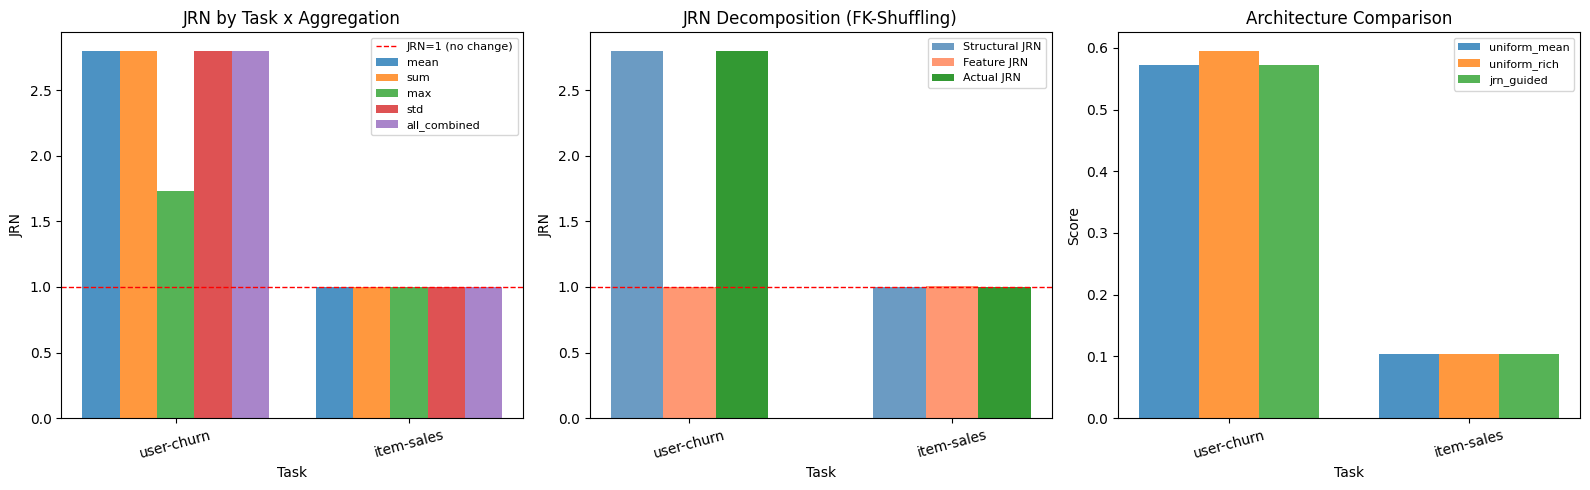


Total runtime: 2.0s


In [14]:
# ===== RESULTS TABLE =====
print("=" * 70)
print("PHASE 1: JRN by Task x Aggregation Type")
print("=" * 70)
print(f"{'Task':<15} {'Agg':<15} {'Baseline':<12} {'Augmented':<12} {'JRN':<8}")
print("-" * 62)
for task_name, task_data in phase1_results.items():
    bl = task_data["baseline"]["mean"]
    for agg_type, agg_data in task_data["agg_results"].items():
        print(f"{task_name:<15} {agg_type:<15} {bl:<12.4f} {agg_data['augmented_mean']:<12.4f} {agg_data['jrn']:<8.4f}")

print("\n" + "=" * 70)
print("PHASE 3: FK-Shuffling Decomposition")
print("=" * 70)
print(f"{'Task':<15} {'Actual JRN':<12} {'Structural':<12} {'Feature':<12}")
print("-" * 51)
for task_name, p3 in phase3_results.items():
    print(f"{task_name:<15} {p3['actual_jrn']:<12.4f} {p3['structural_jrn']:<12.4f} {p3['feature_jrn']:<12.4f}")

print("\n" + "=" * 70)
print("PHASE 4: Aggregation Sensitivity")
print("=" * 70)
for task_name, p4 in phase4_results.items():
    print(f"{task_name}: CoV={p4['cov']:.4f}, Spread={p4['jrn_spread']:.4f}, "
          f"Best={p4['best_agg']}, Worst={p4['worst_agg']}")

print("\n" + "=" * 70)
print("PHASE 5: Architecture Comparison")
print("=" * 70)
print(f"{'Task':<15} {'Uniform-Mean':<14} {'Uniform-Rich':<14} {'JRN-Guided':<14} {'Guidance':<20}")
print("-" * 77)
for task_name, strats in phase5_results.items():
    print(f"{task_name:<15} {strats['uniform_mean']['mean']:<14.4f} "
          f"{strats['uniform_rich']['mean']:<14.4f} {strats['jrn_guided']['mean']:<14.4f} "
          f"{strats['jrn_guided'].get('guidance', 'N/A'):<20}")

# ===== VISUALIZATION =====
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: JRN by task and aggregation type
ax = axes[0]
tasks = list(phase1_results.keys())
agg_types_used = AGG_TYPES
x = np.arange(len(tasks))
width = 0.8 / max(len(agg_types_used), 1)
for i, agg in enumerate(agg_types_used):
    jrns = [phase1_results[t]["agg_results"].get(agg, {}).get("jrn", 0) for t in tasks]
    ax.bar(x + i * width, jrns, width, label=agg, alpha=0.8)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='JRN=1 (no change)')
ax.set_xlabel('Task')
ax.set_ylabel('JRN')
ax.set_title('JRN by Task x Aggregation')
ax.set_xticks(x + width * (len(agg_types_used) - 1) / 2)
ax.set_xticklabels(tasks, rotation=15)
ax.legend(fontsize=8)

# Plot 2: FK-Shuffling decomposition
ax = axes[1]
tasks_p3 = list(phase3_results.keys())
x = np.arange(len(tasks_p3))
structural = [phase3_results[t]["structural_jrn"] for t in tasks_p3]
feature = [phase3_results[t]["feature_jrn"] for t in tasks_p3]
actual = [phase3_results[t]["actual_jrn"] for t in tasks_p3]
ax.bar(x - 0.2, structural, 0.2, label='Structural JRN', color='steelblue', alpha=0.8)
ax.bar(x, feature, 0.2, label='Feature JRN', color='coral', alpha=0.8)
ax.bar(x + 0.2, actual, 0.2, label='Actual JRN', color='green', alpha=0.8)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Task')
ax.set_ylabel('JRN')
ax.set_title('JRN Decomposition (FK-Shuffling)')
ax.set_xticks(x)
ax.set_xticklabels(tasks_p3, rotation=15)
ax.legend(fontsize=8)

# Plot 3: Architecture comparison
ax = axes[2]
tasks_p5 = list(phase5_results.keys())
x = np.arange(len(tasks_p5))
for i, strat in enumerate(["uniform_mean", "uniform_rich", "jrn_guided"]):
    vals = [phase5_results[t][strat]["mean"] for t in tasks_p5]
    ax.bar(x + i * 0.25, vals, 0.25, label=strat, alpha=0.8)
ax.set_xlabel('Task')
ax.set_ylabel('Score')
ax.set_title('Architecture Comparison')
ax.set_xticks(x + 0.25)
ax.set_xticklabels(tasks_p5, rotation=15)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('jrn_results.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"\nTotal runtime: {total_time:.1f}s")